# Exercise 1: (SVM)

## Part 1:

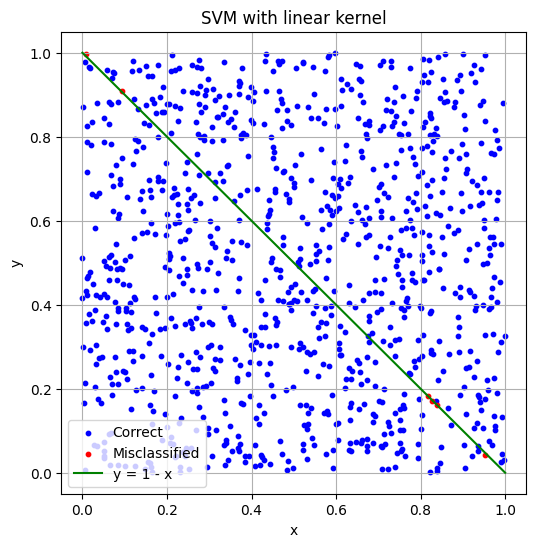

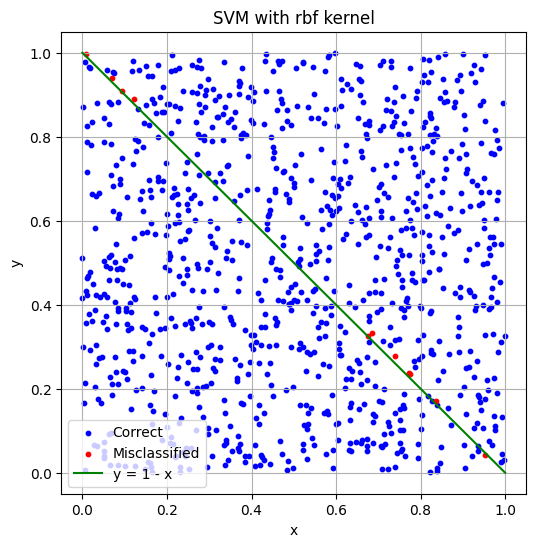

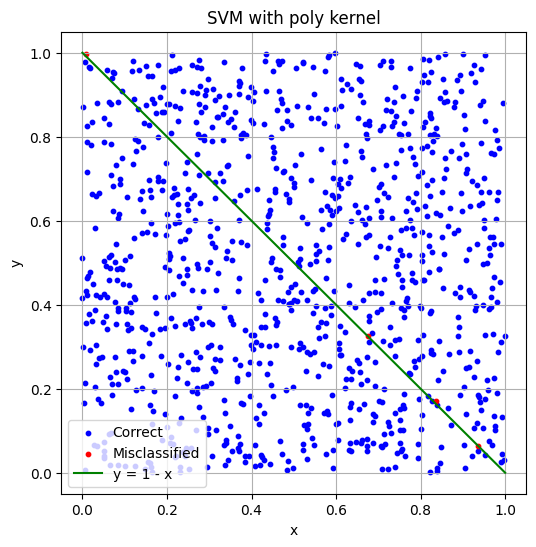

Kernel: linear
  Train Accuracy: 0.99
  Total Train + Test Time: 0.0179 seconds

Kernel: rbf
  Train Accuracy: 0.99
  Total Train + Test Time: 0.0402 seconds

Kernel: poly
  Train Accuracy: 1.00
  Total Train + Test Time: 0.0193 seconds



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from time import time

# Generate train dataset
np.random.seed(42)
X_train = np.random.uniform(0, 1, (1000, 2))
y_train = (X_train[:, 1] > 1 - X_train[:, 0]).astype(int)

# Generate test dataset
X_test = np.random.uniform(0, 1, (1000, 2))

# Define kernels to try
kernels = ['linear', 'rbf', 'poly']
models = {}

# Train and classify using different kernels
results = {}
for kernel in kernels:
    start_time = time()

    # Train SVM
    model = SVC(kernel=kernel, degree=3, gamma='scale')  # Degree used only for poly
    model.fit(X_train, y_train)

    # Predict on test dataset
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate accuracy
    train_accuracy = accuracy_score(y_train, y_pred_train)

    # Mark test points as correctly or incorrectly classified
    test_labels = (X_test[:, 1] > 1 - X_test[:, 0]).astype(int)
    test_correct = y_pred_test == test_labels

    # Save results
    end_time = time()
    models[kernel] = model
    results[kernel] = {
        'train_accuracy': train_accuracy,
        'test_correct': test_correct,
        'train_test_time': end_time - start_time
    }

    # Plot results
    plt.figure(figsize=(6, 6))

    # Plot correctly classified points
    plt.scatter(X_test[test_correct, 0], X_test[test_correct, 1], color='blue', s=10, label='Correct')

    # Plot misclassified points
    plt.scatter(X_test[~test_correct, 0], X_test[~test_correct, 1], color='red', s=10, label='Misclassified')

    # Plot separating line
    x_line = np.linspace(0, 1, 100)
    y_line = 1 - x_line
    plt.plot(x_line, y_line, color='green', label='y = 1 - x')

    # Plot settings
    plt.title(f'SVM with {kernel} kernel')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.show()

# Compare total train and test time
for kernel, result in results.items():
    print(f"Kernel: {kernel}")
    print(f"  Train Accuracy: {result['train_accuracy']:.2f}")
    print(f"  Total Train + Test Time: {result['train_test_time']:.4f} seconds\n")


## Part 2:


Dimension: 2
  Train Accuracy: 1.00
  Test Accuracy: 0.99
  Total Train + Test Time: 0.0083 seconds

Dimension: 3
  Train Accuracy: 1.00
  Test Accuracy: 0.99
  Total Train + Test Time: 0.0125 seconds

Dimension: 5
  Train Accuracy: 0.99
  Test Accuracy: 0.98
  Total Train + Test Time: 0.0165 seconds

Dimension: 10
  Train Accuracy: 1.00
  Test Accuracy: 0.97
  Total Train + Test Time: 0.0228 seconds


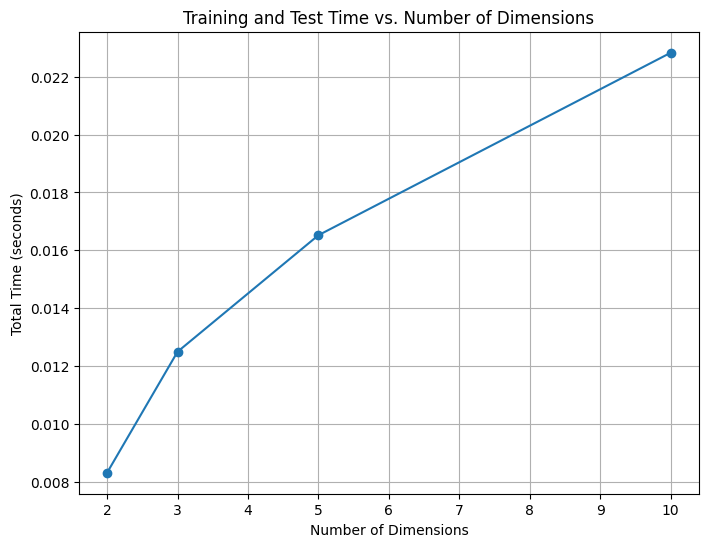

In [2]:
# Function to generate dataset
def generate_dataset(n_points, n_dimensions):
    X = np.random.uniform(0, 1, (n_points, n_dimensions))
    y = (X[:, 1] > 1 - X[:, 0]).astype(int)  # Extend hypothesis to higher dimensions
    return X, y

# Experiment with increasing dimensions
n_dimensions_list = [2, 3, 5, 10]
n_points = 1000
train_test_times = {}

# Loop through dimensions
for n_dimensions in n_dimensions_list:
    print(f"\nDimension: {n_dimensions}")

    # Generate train and test datasets
    X_train, y_train = generate_dataset(n_points, n_dimensions)
    X_test, y_test = generate_dataset(n_points, n_dimensions)

    # Use the best kernel (poly)
    start_time = time()
    model = SVC(kernel='poly', degree=3, gamma='scale')
    model.fit(X_train, y_train)

    # Predict on test dataset
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate accuracy
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)

    # Record training and testing time
    total_time = time() - start_time
    train_test_times[n_dimensions] = total_time

    # Output results
    print(f"  Train Accuracy: {train_accuracy:.2f}")
    print(f"  Test Accuracy: {test_accuracy:.2f}")
    print(f"  Total Train + Test Time: {total_time:.4f} seconds")

# Plot training and test times vs dimensions
plt.figure(figsize=(8, 6))
plt.plot(n_dimensions_list, [train_test_times[d] for d in n_dimensions_list], marker='o')
plt.title('Training and Test Time vs. Number of Dimensions')
plt.xlabel('Number of Dimensions')
plt.ylabel('Total Time (seconds)')
plt.grid()
plt.show()


## Part 3:


Samples: 10, Dimensions: 10

Samples: 10, Dimensions: 50

Samples: 10, Dimensions: 300

Samples: 10, Dimensions: 1000

Samples: 100, Dimensions: 10

Samples: 100, Dimensions: 50

Samples: 100, Dimensions: 300

Samples: 100, Dimensions: 1000

Samples: 1000, Dimensions: 10

Samples: 1000, Dimensions: 50

Samples: 1000, Dimensions: 300

Samples: 1000, Dimensions: 1000

Samples: 5000, Dimensions: 10

Samples: 5000, Dimensions: 50

Samples: 5000, Dimensions: 300

Samples: 5000, Dimensions: 1000


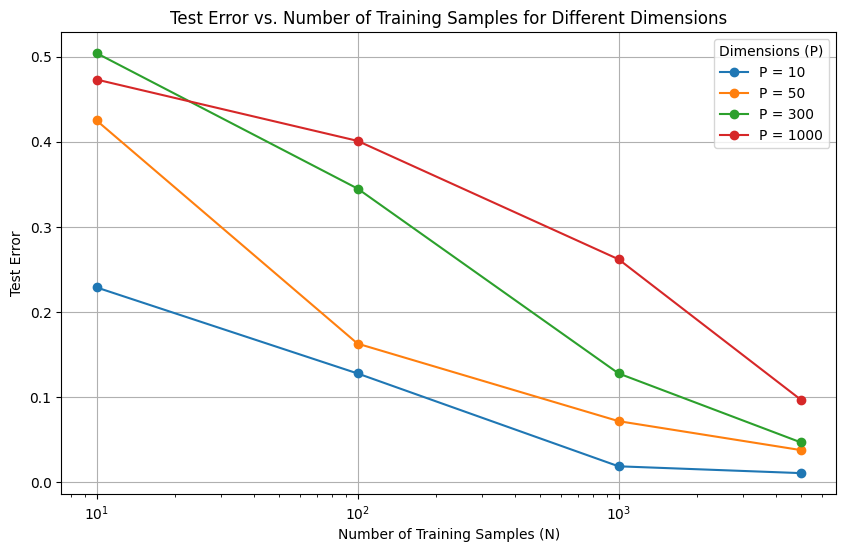

In [4]:
# Define regions for N and P
n_samples_list = [10, 100, 1000, 5000]  # Vary N
n_dimensions_list = [10, 50, 300, 1000]    # Vary P

test_samples = 1000
results = []

# Loop through regions N << P, N = P, N >> P
for n_samples in n_samples_list:
    for n_dimensions in n_dimensions_list:
        print(f"\nSamples: {n_samples}, Dimensions: {n_dimensions}")

        # Generate train and test datasets
        X_train, y_train = generate_dataset(n_samples, n_dimensions)
        X_test, y_test = generate_dataset(test_samples, n_dimensions)

        # Use the best kernel (poly)
        start_time = time()
        model = SVC(kernel='poly', degree=3, gamma='scale')
        model.fit(X_train, y_train)

        # Predict on test dataset
        y_pred_test = model.predict(X_test)

        # Calculate test accuracy
        test_accuracy = accuracy_score(y_test, y_pred_test)
        total_time = time() - start_time

        # Store results
        results.append((n_samples, n_dimensions, test_accuracy, total_time))

# Convert results to numpy array for easy processing
results = np.array(results, dtype=object)

# Plot test error for each region
plt.figure(figsize=(10, 6))
for n_dimensions in n_dimensions_list:
    subset = results[results[:, 1] == n_dimensions]
    plt.plot(subset[:, 0], 1 - subset[:, 2], marker='o', label=f"P = {n_dimensions}")

plt.xscale('log')
plt.title('Test Error vs. Number of Training Samples for Different Dimensions')
plt.xlabel('Number of Training Samples (N)')
plt.ylabel('Test Error')
plt.legend(title="Dimensions (P)")
plt.grid()
plt.show()


## **Conclusion:** More dimensions you have, slower conversion to zero test error it will be as we can see and as we get larger number of training samples increase the test error decrease.

## Part 4:


Using linear kernel (degree=1)


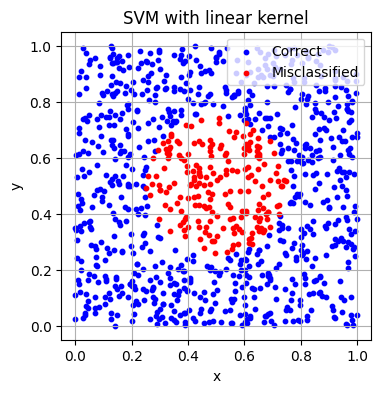


Using poly kernel (degree=2)


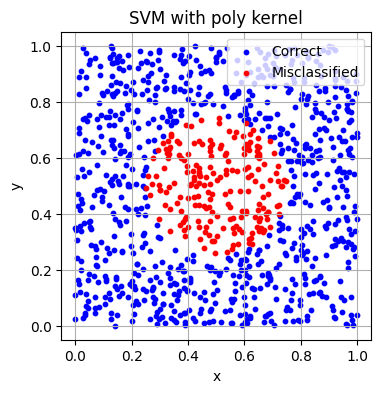

Kernel: linear
  Test Accuracy: 0.80
  Total Time: 0.0179 seconds

Kernel: poly
  Test Accuracy: 0.80
  Total Time: 0.0292 seconds



In [22]:
def generate_circular_dataset(n_points):
    X = np.random.uniform(0, 1, (n_points, 2))
    center = np.array([0.5, 0.5])
    radius = 0.25
    distances = np.sqrt((X[:, 0] - center[0])**2 + (X[:, 1] - center[1])**2)
    y = (distances <= radius).astype(int)
    return X, y

# Parameters
n_samples = 1000

# Generate train and test datasets
X_train, y_train = generate_circular_dataset(n_samples)
X_test, y_test = generate_circular_dataset(n_samples)

# Kernels to test
kernels = ['linear', 'poly']
results = {}

for kernel in kernels:
    degree = 2 if kernel == 'poly' else 1
    print(f"\nUsing {kernel} kernel (degree={degree})")

    # Train and test SVM
    start_time = time()
    model = SVC(kernel=kernel, degree=degree, gamma='scale')
    model.fit(X_train, y_train)

    # Predict on test dataset
    y_pred_test = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    total_time = time() - start_time

    # Store results
    results[kernel] = {
        'test_accuracy': test_accuracy,
        'total_time': total_time
    }

    # Plot results
    plt.figure(figsize=(4, 4))
    correctly_classified = (((y_test == 1) & (y_pred_test == 1)) | ((y_test == 0) & (y_pred_test == 0)))
    misclassified = ~correctly_classified
    plt.scatter(X_test[correctly_classified, 0], X_test[correctly_classified, 1], color='blue', s=10, label='Correct')
    plt.scatter(X_test[misclassified, 0], X_test[misclassified, 1], color='red', s=10, label='Misclassified')
    plt.title(f'SVM with {kernel} kernel')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.show()

# Print results
for kernel, result in results.items():
    print(f"Kernel: {kernel}")
    print(f"  Test Accuracy: {result['test_accuracy']:.2f}")
    print(f"  Total Time: {result['total_time']:.4f} seconds\n")


# Exercise 2: (Bayesian)

## Read the Articles and more.